# Import libraries

In [936]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error
)

In [937]:
SHIFT = 24

# Load data

In [938]:
df = pd.read_parquet("../data/merged_data.parquet")

# Feature engineering

## Missing values

In [939]:
df = df.iloc[28000:]

In [940]:
df = df.drop("wind_gust", axis=1)
df = df.dropna(subset="temp")

In [941]:
df = df.ffill()

## Date features

In [942]:
def is_weekend(day_of_week: int) -> int:
    match day_of_week:
        case 0 | 7:
            return 1
        case _:
            return 0
        
def is_new_years(timestamp) -> bool:
    if ((timestamp.month == 12 and timestamp.day_of_week == 31) 
        or 
        (timestamp.month == 1 and timestamp.day_of_week == 1)):
        return True
    else:
        return False

In [943]:
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_of_week
df['hour_of_day'] = df['timestamp'].dt.hour
df['is_weekend'] = df['day_of_week'].apply(lambda day: is_weekend(day))
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2* np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2* np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['is_new_year'] = df["timestamp"].apply(lambda x: is_new_years(x))

## Rolling & lag

In [944]:
df = df.rename(columns={"value": "pm25"})

In [945]:
df.columns

Index(['pm25', 'timestamp', 'temp', 'feels_like', 'pressure', 'humidity',
       'dew_point', 'wind_speed', 'wind_deg', 'year', 'month', 'day_of_week',
       'hour_of_day', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin',
       'month_cos', 'day_sin', 'day_cos', 'is_new_year'],
      dtype='object')

In [946]:
target = 'pm25'
targets = ["pm25", "temp", "feels_like", "pressure", "humidity", "wind_speed"]
lag_periods = [3, 6, 12, 24]
rolling_window = [3, 6]

In [947]:
for targ in targets:
    for window in rolling_window:
        df[f'rolling_{targ}_{str(window)}'] = df[targ].rolling(window=window).mean()

    for period in lag_periods:
        df[f'lag_{targ}_{str(period)}'] = df[targ].shift(periods=period)

df['wind_deg_sin'] = np.sin(2 * np.pi * df['wind_deg'] / 360)
df['wind_deg_cos'] = np.cos(2 * np.pi * df['wind_deg'] / 360)

In [948]:
forecast_features = ['temp', 'feels_like', 'pressure', 'humidity']
forecast_periods = [3, 6, 12, 24]

for forecast_feature in forecast_features:
    for period in forecast_periods:
        df[f'forecast_{forecast_feature}_{str(period)}'] = df[forecast_feature].shift(periods=-1*period)

In [949]:
df.tail()

,pm25,timestamp,temp,feels_like,pressure,humidity,dew_point,wind_speed,wind_deg,year,...,forecast_feels_like_12,forecast_feels_like_24,forecast_pressure_3,forecast_pressure_6,forecast_pressure_12,forecast_pressure_24,forecast_humidity_3,forecast_humidity_6,forecast_humidity_12,forecast_humidity_24
52627,19.1,2026-01-01 19:00:00+00:00,274.67,270.44,1008.0,69.0,270.02,4.47,286.0,2026,...,NaN,NaN,1007.0,NaN,NaN,NaN,62.0,NaN,NaN,NaN
52628,20.4,2026-01-01 20:00:00+00:00,274.51,271.57,1008.0,69.0,269.88,2.68,246.0,2026,...,NaN,NaN,1007.0,NaN,NaN,NaN,61.0,NaN,NaN,NaN
52629,20.4,2026-01-01 21:00:00+00:00,274.51,271.57,1008.0,69.0,269.88,2.68,279.0,2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52630,17.2,2026-01-01 22:00:00+00:00,274.12,271.10,1007.0,62.0,268.29,2.68,267.0,2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52631,13.6,2026-01-01 23:00:00+00:00,273.40,270.70,1007.0,61.0,267.49,2.24,267.0,2026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [950]:
tst = pd.DataFrame(data={
    "pm25": [i for i in range(20)]
})

## Target

In [951]:
target_type = "SHIFT"

if target_type == "SHIFT":
    df['target'] = df[target].shift(-SHIFT)

if target_type == "12_HOUR_AVG":
    df['target'] = df[target].rolling(12).mean()

if target_type == "6_HOUR_AVG":
    df['target'] = df[target].rolling(6).mean()

if target_type == "ROLLING_AVG_SHIFT":
    df['target'] = df[target].rolling(3).mean().shift(-2)

df = df.dropna()
df.shape

(24432, 76)

In [952]:
root_mean_squared_error(df['pm25'], df['target'])

11.978545649174263

# Create data splits

In [953]:
assert ~df.isna().sum(axis=0).any(), "Still contains nulls"

In [954]:
train_idx = int(np.ceil(len(df) * .9))
print(train_idx)

21989


In [955]:
train_df = df.iloc[:train_idx, :]
test_df = df.iloc[train_idx:, :]
print(train_df.shape, test_df.shape)

(21989, 76) (2443, 76)


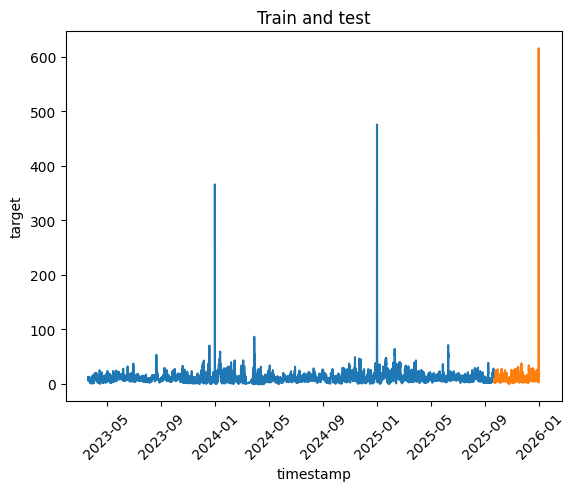

In [956]:
y_vis = "target"
sns.lineplot(train_df, x="timestamp", y=y_vis)
sns.lineplot(test_df, x="timestamp", y=y_vis)
plt.title("Train and test")
plt.xticks(rotation=45)
plt.show()

In [957]:
train_df.columns

Index(['pm25', 'timestamp', 'temp', 'feels_like', 'pressure', 'humidity',
       'dew_point', 'wind_speed', 'wind_deg', 'year', 'month', 'day_of_week',
       'hour_of_day', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin',
       'month_cos', 'day_sin', 'day_cos', 'is_new_year', 'rolling_pm25_3',
       'rolling_pm25_6', 'lag_pm25_3', 'lag_pm25_6', 'lag_pm25_12',
       'lag_pm25_24', 'rolling_temp_3', 'rolling_temp_6', 'lag_temp_3',
       'lag_temp_6', 'lag_temp_12', 'lag_temp_24', 'rolling_feels_like_3',
       'rolling_feels_like_6', 'lag_feels_like_3', 'lag_feels_like_6',
       'lag_feels_like_12', 'lag_feels_like_24', 'rolling_pressure_3',
       'rolling_pressure_6', 'lag_pressure_3', 'lag_pressure_6',
       'lag_pressure_12', 'lag_pressure_24', 'rolling_humidity_3',
       'rolling_humidity_6', 'lag_humidity_3', 'lag_humidity_6',
       'lag_humidity_12', 'lag_humidity_24', 'rolling_wind_speed_3',
       'rolling_wind_speed_6', 'lag_wind_speed_3', 'lag_wind_speed_6',
      

In [958]:
X_COLS = [
    'pm25', 'temp', 'feels_like', 'pressure', 'humidity',
       'dew_point', 'wind_speed', 'wind_deg', 'year', 'month', 'day_of_week',
       'hour_of_day', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin',
       'month_cos', 'day_sin', 'day_cos', 'is_new_year', 'rolling_pm25_3',
       'rolling_pm25_6', 'lag_pm25_3', 'lag_pm25_6', 'lag_pm25_12',
       'rolling_temp_3', 'rolling_temp_6', 'lag_temp_3', 'lag_temp_6',
       'lag_temp_12', 'rolling_feels_like_3', 'rolling_feels_like_6',
       'lag_feels_like_3', 'lag_feels_like_6', 'lag_feels_like_12',
       'rolling_pressure_3', 'rolling_pressure_6', 'lag_pressure_3',
       'lag_pressure_6', 'lag_pressure_12', 'rolling_humidity_3',
       'rolling_humidity_6', 'lag_humidity_3', 'lag_humidity_6',
       'lag_humidity_12', 'rolling_wind_speed_3', 'rolling_wind_speed_6',
       'lag_wind_speed_3', 'lag_wind_speed_6', 'lag_wind_speed_12',
       'wind_deg_sin', 'wind_deg_cos', 'forecast_temp_3', 'forecast_temp_6',
       'forecast_temp_12', 'forecast_feels_like_3', 'forecast_feels_like_6',
       'forecast_feels_like_12', 'forecast_pressure_3', 'forecast_pressure_6',
       'forecast_pressure_12', 'forecast_humidity_3', 'forecast_humidity_6',
       'forecast_humidity_12',
]

Y_COL = [
    "target"
]

In [959]:
X_train = train_df.loc[:, X_COLS]
y_train = train_df.loc[:, 'target']

X_test = test_df.loc[:, X_COLS]
y_test = test_df.loc[:, 'target']

train_timestamp = train_df.loc[:, 'timestamp']
test_timestamp = test_df.loc[:, 'timestamp']

# Train model

## Baseline (Ridge)

In [960]:
clf = Ridge(alpha=1.0)
clf.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [961]:
y_hat = clf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_hat)
r2 = r2_score(y_test, y_hat)

print("RMSE", rmse)
print("r2", r2)

RMSE 14.960844250948606
r2 0.02479648520913713


In [962]:
y_hat_df = pd.DataFrame(
    data={
        "timestamp": test_timestamp,
        "truth": y_test,
        "pred": y_hat
    }
)
y_hat_df.head(10)

,timestamp,truth,pred
50165,2025-09-21 05:00:00+00:00,3.20,9.280371
50166,2025-09-21 06:00:00+00:00,3.12,10.063602
50167,2025-09-21 07:00:00+00:00,3.40,9.822476
50168,2025-09-21 08:00:00+00:00,3.23,10.107244
50169,2025-09-21 09:00:00+00:00,4.19,10.696092
50170,2025-09-21 10:00:00+00:00,6.00,9.979781
50171,2025-09-21 11:00:00+00:00,8.40,9.897304
50172,2025-09-21 12:00:00+00:00,9.12,9.961234
50173,2025-09-21 13:00:00+00:00,5.62,10.056244
50174,2025-09-21 14:00:00+00:00,7.01,9.704826


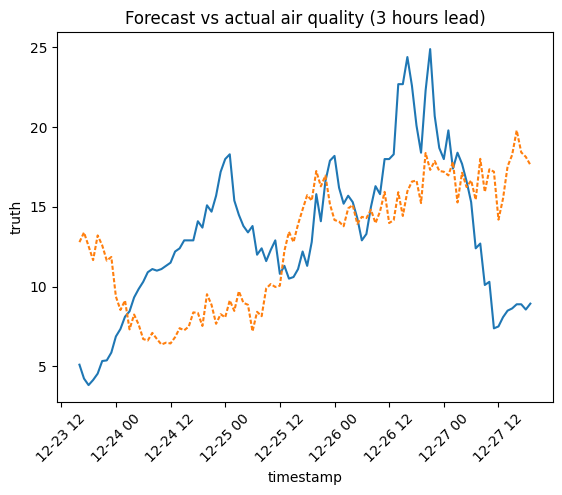

In [963]:
sns.lineplot(y_hat_df[-200:-100], x="timestamp", y="truth")
sns.lineplot(y_hat_df[-200:-100], x="timestamp", y="pred", dashes=[2, 1])

plt.title("Forecast vs actual air quality (3 hours lead)")
plt.xticks(rotation=45)
plt.show()

In [964]:
y_hat_df.head()

,timestamp,truth,pred
50165,2025-09-21 05:00:00+00:00,3.20,9.280371
50166,2025-09-21 06:00:00+00:00,3.12,10.063602
50167,2025-09-21 07:00:00+00:00,3.40,9.822476
50168,2025-09-21 08:00:00+00:00,3.23,10.107244
50169,2025-09-21 09:00:00+00:00,4.19,10.696092


In [965]:
pd.DataFrame(data={
    "coef": clf.coef_,
    "feature": clf.feature_names_in_
}) \
    .sort_values('coef', ascending=False) \
    .reset_index() \
    .drop('index', axis=1)

,coef,feature
0,1.181915,wind_deg_sin
1,1.045331,rolling_feels_like_6
2,0.499137,is_new_year
3,0.487789,forecast_feels_like_12
4,0.434291,hour_cos
...,...,...
59,-0.479458,lag_temp_12
60,-0.491928,dew_point
61,-0.780864,month_sin
62,-1.028835,rolling_temp_6


In [966]:
df.groupby('month').agg({
    'target': 'mean'
})

,target
month,
1,12.823340
2,14.361162
3,9.500653
4,8.720273
5,9.059892
6,10.720514
7,8.570188
8,10.087280
9,9.013977


# Final remarks
At the end of this experiment, we observe the following:
- Predicting a shifted target precisely is extremely hard. The model never performs better than simply guessing the current pm2.5 value.

# LightGBM

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10652
[LightGBM] [Info] Number of data points in the train set: 21989, number of used features: 64
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 w

/home/luc/Documents/Projects/air_quality/.venv/lib/python3.10/site-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
R2 Score: 0.0225
RMSE: 14.9785


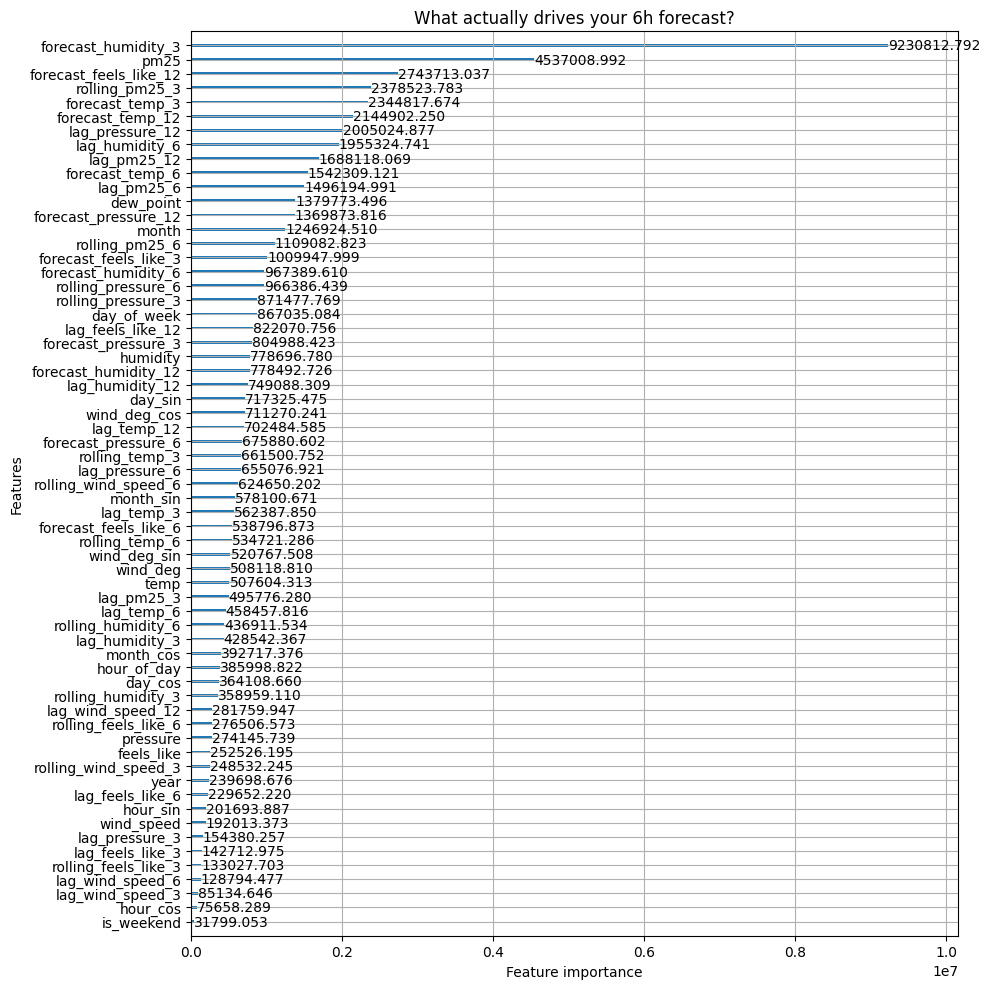

In [967]:
import lightgbm as lgb
import matplotlib.pyplot as plt

model = lgb.LGBMRegressor(
    boosting_type='dart',
    objective='regression',
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=1000,      
    feature_fraction=0.8,   
    bagging_fraction=0.7,   
    bagging_freq=5,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

lgb.plot_importance(model, importance_type='gain', figsize=(10, 10))
plt.title("What actually drives your 6h forecast?")
plt.tight_layout()
plt.show()

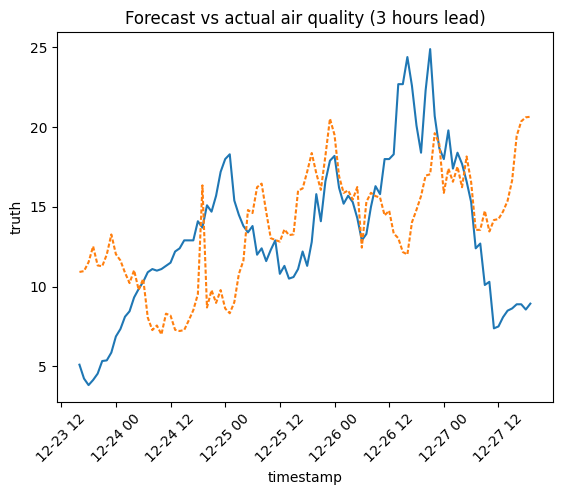

In [968]:
y_hat_df = pd.DataFrame(
    data={
        "timestamp": test_timestamp,
        "truth": y_test,
        "pred": y_pred
    }
)

sns.lineplot(y_hat_df[-200:-100], x="timestamp", y="truth")
sns.lineplot(y_hat_df[-200:-100], x="timestamp", y="pred", dashes=[2, 1])

plt.title("Forecast vs actual air quality (3 hours lead)")
plt.xticks(rotation=45)
plt.show()

# Prophet

In [969]:
from prophet import Prophet

In [970]:
prophet_df = df.loc[:, ["timestamp", "pm25"]]
prophet_df = prophet_df.rename(columns={"timestamp":"ds", "pm25":"y"})

In [971]:
prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

In [972]:
m = Prophet()
m.fit(prophet_df)

19:17:12 - cmdstanpy - INFO - Chain [1] start processing
19:17:17 - cmdstanpy - INFO - Chain [1] done processing


In [973]:
# Python
future = m.make_future_dataframe(periods=48)
future.tail()

,ds
24475,2026-02-13 23:00:00
24476,2026-02-14 23:00:00
24477,2026-02-15 23:00:00
24478,2026-02-16 23:00:00
24479,2026-02-17 23:00:00


In [974]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
24475,2026-02-13 23:00:00,22.216464,10.300378,33.327582
24476,2026-02-14 23:00:00,22.361688,10.870887,33.499611
24477,2026-02-15 23:00:00,21.287956,10.109730,32.346538
24478,2026-02-16 23:00:00,22.277444,10.558499,33.865299
24479,2026-02-17 23:00:00,22.412449,10.629642,33.741686


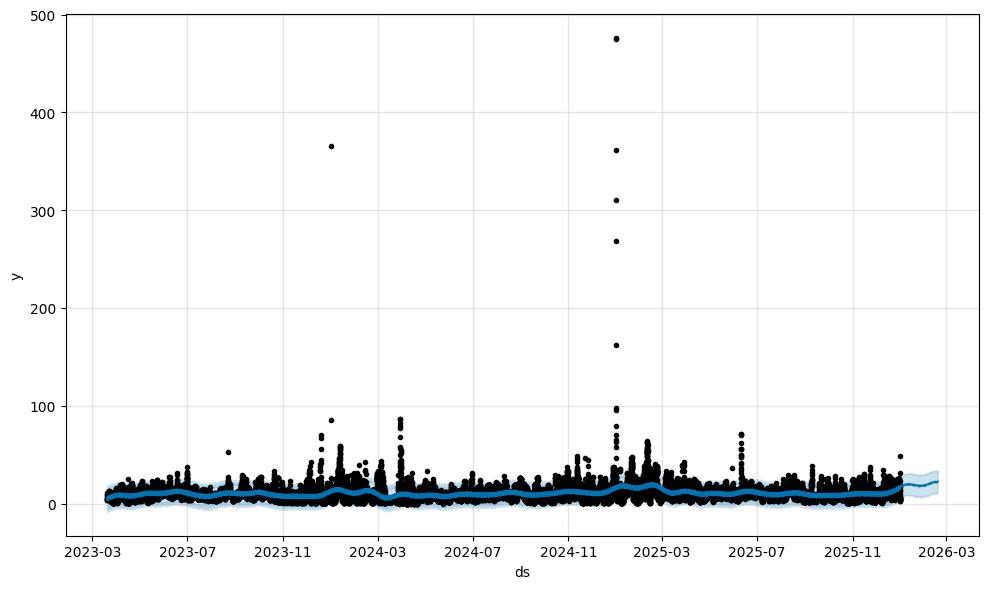

In [975]:
fig1 = m.plot(forecast)

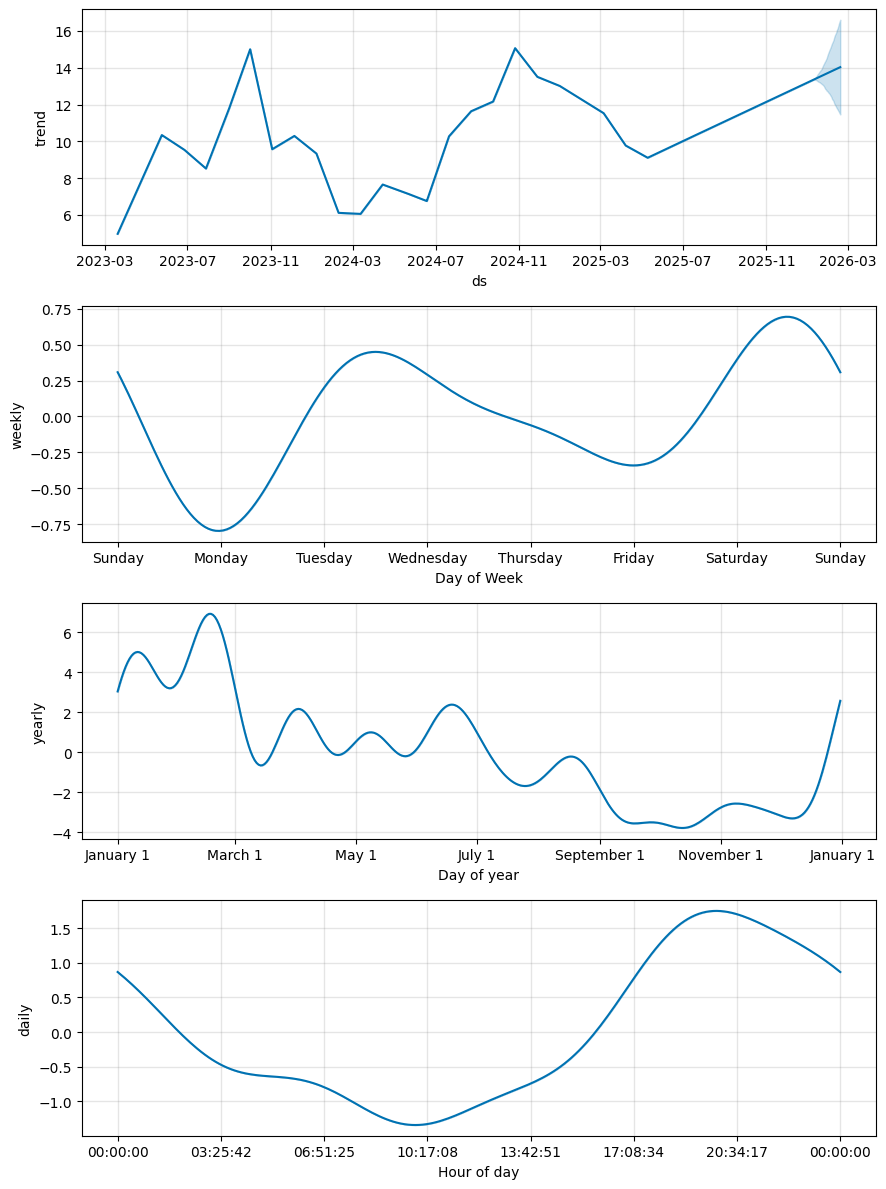

In [976]:
fig2 = m.plot_components(forecast)

In [977]:
df.describe()

,pm25,temp,feels_like,pressure,humidity,dew_point,wind_speed,wind_deg,year,month,...,forecast_feels_like_24,forecast_pressure_3,forecast_pressure_6,forecast_pressure_12,forecast_pressure_24,forecast_humidity_3,forecast_humidity_6,forecast_humidity_12,forecast_humidity_24,target
count,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,...,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000,24432.000000
mean,10.045053,284.554585,283.922754,1017.042403,79.153446,280.629715,1.623315,191.302268,2024.076621,6.880157,...,283.910477,1017.042567,1017.042362,1017.040766,1017.034831,79.151727,79.150786,79.148617,79.143418,10.108463
std,9.106813,8.103452,8.615679,8.265498,16.146864,6.328853,1.133243,94.547824,0.796635,3.310078,...,8.628042,8.265571,8.265505,8.265263,8.267199,16.146167,16.145605,16.146313,16.151000,10.142939
min,-1.000000,260.650000,255.170000,980.000000,22.000000,259.610000,0.020000,0.000000,2023.000000,1.000000,...,255.170000,980.000000,980.000000,980.000000,980.000000,22.000000,22.000000,22.000000,22.000000,-1.000000
25%,5.410000,278.580000,277.570000,1012.000000,69.000000,275.817500,0.890000,104.000000,2023.000000,4.000000,...,277.540000,1012.000000,1012.000000,1012.000000,1012.000000,69.000000,69.000000,69.000000,69.000000,5.420000
50%,8.660000,284.260000,283.560000,1017.000000,85.000000,280.770000,1.340000,216.000000,2024.000000,7.000000,...,283.550000,1017.000000,1017.000000,1017.000000,1017.000000,85.000000,85.000000,85.000000,85.000000,8.660000
75%,12.800000,290.080000,289.910000,1022.000000,92.000000,285.602500,2.240000,273.000000,2025.000000,10.000000,...,289.910000,1022.000000,1022.000000,1022.000000,1022.000000,92.000000,92.000000,92.000000,92.000000,12.800000
max,476.000000,308.740000,309.440000,1044.000000,100.000000,295.210000,19.620000,360.000000,2025.000000,12.000000,...,309.440000,1044.000000,1044.000000,1044.000000,1044.000000,100.000000,100.000000,100.000000,100.000000,616.000000
